In [106]:
# Imports
import numpy as np
import pandas as pd
import statsmodels.api as sm
import ast
import re
from tqdm import tqdm

# Load files
print("Loading data...")
trial_table = pd.read_csv(r'C:\Users\mhamon\Downloads\GLM\GLM\data/trial_table_final.csv')
beh_trial_avg = pd.read_csv(r'C:\Users\mhamon\Downloads\GLM\GLM\data/behavior_trial_avg.csv')
beh_time_series = pd.read_csv(r'C:\Users\mhamon\Downloads\GLM\GLM\data/behavior_time_series.csv')
neuronal_activity = pd.read_csv(r'C:\Users\mhamon\Downloads\GLM\GLM\data/neuronal_activity.csv') # T x N_neurons


Loading data...


In [ ]:
trial_table[(trial_table['is_change'] ==False) & (trial_table['initial_image_name'] == 'im078_r')]

In [ ]:
trial_table.iloc[0]

In [2]:
# Initialize session data
sesh_duration = trial_table['stop_time'].max()
time = np.arange(0, sesh_duration, 0.025) # s

kernel_widths = {
    'visual': 0.75,
    'hit': 1.5,
    'miss': 1.5,
    'running': 2.0,
    'pupil': 2.0,
    'lick': 2.0,
    'engagement': 2.0 # default as it is not in the paper, same as lick
}


In [89]:
# --------------------------------------------- #
# 1. Create Regressors                          #
# --------------------------------------------- #
def build_regressors(trial_table=trial_table, time=time):
    ''' Build regressors from trial table and behavioral data.
    ---
    Returns:
        design_matrix: DataFrame of shape (T, P) where T is number of time bins and P is number of regressors
    '''
    regressors = {}
    # Visual Features
    #   1 regressor per unique image (8 total)
    images = trial_table['initial_image_name'].unique()

    for image in tqdm(images, desc="Creating visual regressors"):
        img_onsets = trial_table[trial_table['initial_image_name'] == image]['change_time_with_display_delay'].values
        regressor = np.zeros_like(time)
        for onset in img_onsets:
            idx = np.searchsorted(time, onset)
            if idx < len(regressor):
                regressor[idx] = 1
        regressors[image] = regressor

    # Task Features
    #   Hits
    hit_onsets = trial_table[trial_table['hit']]['change_time_with_display_delay'].values
    hit_indices = np.searchsorted(time, hit_onsets)
    hit_reg = np.zeros_like(time)
    hit_reg[hit_indices] = 1
    regressors['hit'] = hit_reg

    #   Misses
    miss_onsets = trial_table[trial_table['miss']]['change_time_with_display_delay'].values
    miss_indices = np.searchsorted(time, miss_onsets)
    miss_reg = np.zeros_like(time)
    miss_reg[miss_indices] = 1
    regressors['miss'] = miss_reg

    #   Licks
    licks = np.loadtxt(r'C:\Users\mhamon\Downloads\GLM\GLM\data/lick_regressor.csv') # Assuming this file contains lick regressor time series
    regressors['lick'] = licks

    #   Running Speed (!!!check)
    raw_speed = pd.read_csv(r'C:\Users\mhamon\Downloads\GLM\GLM\data/running_data.csv') # Assuming this file contains running speed time series
    indices = np.searchsorted(raw_speed['time'], time, side='right') - 1
    indices[indices < 0] = 0
    regressors['running'] = raw_speed['speed'].values[indices]

    #   Pupil Diameter
    raw_pupil = pd.read_csv(r'C:\Users\mhamon\Downloads\GLM\GLM\data/pupil_data.csv') # Assuming this file contains pupil diameter time series
    indices = np.searchsorted(raw_pupil['time'], time, side='right') - 1
    indices[indices < 0] = 0
    regressors['pupil'] = raw_pupil['pupil_x'].values[indices]

    #   Engagement State
    engagement_reg = np.zeros_like(time)

    # Loop over trials
    for i, trial in tqdm(trial_table.iterrows(), total=len(trial_table), desc="Processing engagement"):

        engaged = trial["engag_bool"] == 1
        if not engaged:
            continue

        # Get trial window
        t0 = trial["start_time"]
        t1 = trial["stop_time"]

        # Convert times to indices in the GLM grid
        start_idx = np.searchsorted(time, t0, side="left")
        end_idx   = np.searchsorted(time, t1, side="right")

        # Fill with 1's during the engaged trial
        engagement_reg[start_idx:end_idx] = 1

    regressors['engagement'] = engagement_reg
    return regressors

print("Building regressors...")
regressors = build_regressors()

# Turn regressors into DataFrame
design_matrix = pd.DataFrame(regressors)
design_matrix.index = pd.Index(time) # make time the index, just to keep track


Building regressors...


Processing engagement: 100%|██████████| 221/221 [00:00<00:00, 87348.40it/s]


In [45]:
design_matrix.keys()

Index(['im083_r', 'im012_r', 'im044_r', 'im047_r', 'im036_r', 'im078_r',
       'im111_r', 'im115_r', 'hit', 'miss', 'lick', 'running', 'pupil',
       'engagement'],
      dtype='object')

In [90]:
design_matrix['running'] = (design_matrix['running'] - design_matrix['running'].mean() ) /design_matrix['running'].std()

In [91]:
design_matrix['pupil'] = (design_matrix['pupil'] - design_matrix['pupil'].mean() ) /design_matrix['pupil'].std()

In [30]:
np.where(design_matrix['im083_r'] == 1)[0][0]

np.int64(3515)

In [42]:
15*0.025

0.375

In [48]:
design_matrix = design_matrix.iloc[3300:3800]

In [39]:
design_matrix

,im083_r,im012_r,im044_r,im047_r,im036_r,im078_r,im111_r,im115_r,hit,miss,lick,running,pupil,engagement
87.500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.103223,-0.006562,0.0
87.525,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.087042,0.017146,0.0
87.550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.077003,0.023610,0.0
87.575,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.076441,0.168083,0.0
87.600,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.095828,0.246176,0.0
87.625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.126661,0.228553,0.0
87.650,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.233271,0.279250,0.0
87.675,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.298060,0.199965,0.0
87.700,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.423259,0.229221,0.0
87.725,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.478801,0.276852,0.0


In [107]:
neuronal_activity = neuronal_activity.to_numpy()

In [108]:
neuronal_activity = neuronal_activity[:,96]

In [95]:

def make_toeplitz(dm, regressor_name, kernel_width, dt=0.025):
    ''' Create a Toeplitz matrix for a given regressor and kernel width. 
    ---
    Parameters:
        regressor: 1D array of shape (T,)
        kernel_width: float, width of the kernel in seconds
        dt: float, time resolution of the regressor in seconds
    ---
    Returns:
        toeplitz_matrix: 2D array of shape (T, L) where L = kernel_width / dt (number of lags)
    '''
    regressor = dm[regressor_name].values
    L = int(kernel_width / dt)
    T = len(regressor)
    block = np.zeros((T, L), dtype=float)

    for lag in range(L):
        # row t gets feature[t - lag]
        block[lag:, lag] = regressor[:T - lag]

    block = pd.DataFrame(block, index=design_matrix.index, columns=[f'{regressor_name}_lag{i}' for i in range(L)])
    return block


def make_design_matrix(design_matrix, kernel_widths):
    ''' Build full design matrix with Toeplitz blocks for each regressor.
    ---
    Parameters:
        design_matrix: DataFrame of shape (T, P) with original regressors
        kernel_widths: dict mapping regressor names to kernel widths in seconds
    ---
    Returns:
        full_design_matrix: DataFrame of shape (T, P_total) with Toeplitz blocks
    '''
    blocks = []
    for feature in tqdm(design_matrix.columns, desc="Building Toeplitz matrices"):
        kernel_width = kernel_widths.get(
        "visual" if re.search(r"^im.*_r$", feature) else feature, # regex to match image features, which are named after the image
        1.0
        )
        toeplitz_block = make_toeplitz(design_matrix, feature, kernel_width)
        blocks.append(toeplitz_block)

    design_matrix = pd.concat(blocks, axis=1)

    return design_matrix

design_matrix = make_design_matrix(design_matrix, kernel_widths)

Building Toeplitz matrices: 100%|██████████| 14/14 [00:00<00:00, 31.78it/s]


In [ ]:
design_matrix.head()

In [7]:
neuronal_activity = neuronal_activity.to_numpy()

In [8]:
np.argmax(neuronal_activity.mean(0))


np.int64(96)

In [9]:
neuronal_activity = neuronal_activity[:,96]

In [96]:
# Source - https://stackoverflow.com/a
# Retrieved 2025-12-01, License - CC BY-SA 4.0

import scipy.ndimage

def halfgaussian_kernel1d(sigma, radius):
    """
    Computes a 1-D Half-Gaussian convolution kernel.
    """
    sigma2 = sigma * sigma
    x = np.arange(0, radius+1)
    phi_x = np.exp(-0.5 / sigma2 * x ** 2)
    phi_x = phi_x / phi_x.sum()

    return phi_x

def halfgaussian_filter1d(input, sigma, axis=-1, output=None,
                      mode="constant", cval=0.0, truncate=4.0):
    """
    Convolves a 1-D Half-Gaussian convolution kernel.
    """
    sd = float(sigma)
    # make the radius of the filter equal to truncate standard deviations
    lw = int(truncate * sd + 0.5)
    weights = halfgaussian_kernel1d(sigma, lw)
    origin = -lw // 2
    return scipy.ndimage.convolve1d(input, weights, axis, output, mode, cval, origin)


In [97]:
neuronal_activity = halfgaussian_filter1d(neuronal_activity, 20)

In [110]:
10/0.025

400.0

In [98]:
def fit_kernels(W, neuronal_activity, lam):
    """
    W : (T x P) design matrix, P sum of all lags across features
    neuronal_activity : (T x n_units) all bins of spike activity for all units
    lam : scalar ridge penalty
    
    Returns:
        X : (P x n_units) matrix of all kernel weights
    """
    
    columns = W.columns
    W = W.values  # Convert to numpy array
    WT = W.T
    P = WT @ W
    reg = lam * np.eye(P.shape[0])
    inv_term = np.linalg.inv(P + reg)

    X = inv_term @ (WT @ neuronal_activity)
    X = pd.DataFrame(X)
    return X


print("Fitting kernels...")
X = fit_kernels(
    design_matrix,
    neuronal_activity,
    lam=1.0
)




Fitting kernels...


In [58]:
design_matrix.shape

(500, 680)

In [63]:
neuronal_activity.shape

(500,)

In [99]:
def predict_activity(W, X):
    ''' Predict neuronal activity given design matrix W and kernel weights X.
    ---
    Parameters:
        W: DataFrame of shape (T, P) design matrix
        X: DataFrame of shape (P, n_units) kernel weights
    ---
    Returns:
        predicted_activity: DataFrame of shape (T, n_units)
    '''
    predicted = W.values @ X.values
    predicted_activity = pd.DataFrame(predicted, index=W.index, columns=X.columns)
    return predicted_activity


In [100]:
predicted = predict_activity(design_matrix, X)

In [102]:
predicted = predicted.to_numpy()

In [65]:
neuronal_activity =neuronal_activity.reshape(-1,1)

In [ ]:
neuronal_activity.shape

In [70]:
predicted.shape

(500, 1)

In [17]:
import matplotlib.pyplot as plt

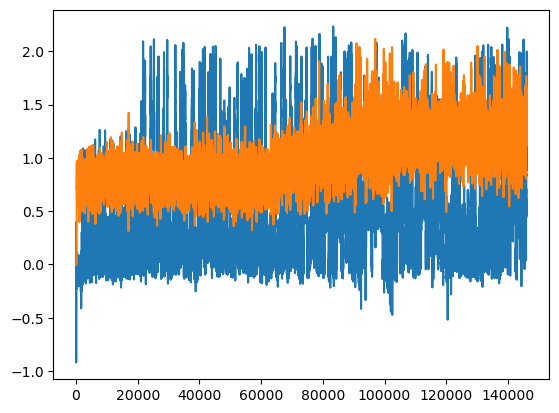

In [103]:
# plt.plot(predicted[1550:1655])
plt.plot(predicted)


plt.plot(neuronal_activity)


In [104]:
def explained_variance(y, yhat):
    ss_res = np.sum((y - yhat)**2, axis=0)
    ss_tot = np.sum((y - np.mean(y, axis=0))**2, axis=0)
    ev = 1 - ss_res / ss_tot
    return np.nan_to_num(ev, nan=0.0)

In [105]:
explained_variance(predicted.flatten(), neuronal_activity.flatten())

np.float64(-0.9538010593318937)

In [72]:
predicted.shape

(500, 1)

In [73]:
neuronal_activity.shape

(500, 1)

In [ ]:
predicted.head()

In [113]:
T

146168

In [138]:
n_intervals = 50
n_folds = 5
intervals_per_fold = n_intervals // n_folds
lambdas = np.exp(np.linspace(np.log(100), np.log(1e-5), 30))
rng = np.random.default_rng(0)  

Xdm = design_matrix.copy()
Y = neuronal_activity.copy()
T = Xdm.shape[0]


# build interval id per row
base_sizes = np.full(n_intervals, T // n_intervals, dtype=int)
remainder = T % n_intervals
if remainder > 0:
    base_sizes[:remainder] += 1
interval_ids = np.repeat(np.arange(n_intervals), base_sizes)
assert interval_ids.size == T

In [139]:
lambdas

array([1.00000000e+02, 5.73615251e+01, 3.29034456e+01, 1.88739182e+01,
       1.08263673e+01, 6.21016942e+00, 3.56224789e+00, 2.04335972e+00,
       1.17210230e+00, 6.72335754e-01, 3.85662042e-01, 2.21221629e-01,
       1.26896100e-01, 7.27895384e-02, 4.17531894e-02, 2.39502662e-02,
       1.37382380e-02, 7.88046282e-03, 4.52035366e-03, 2.59294380e-03,
       1.48735211e-03, 8.53167852e-04, 4.89390092e-04, 2.80721620e-04,
       1.61026203e-04, 9.23670857e-05, 5.29831691e-05, 3.03919538e-05,
       1.74332882e-05, 1.00000000e-05])

In [119]:
ev_units = explained_variance(Y_test, Y_pred)

In [120]:
ev_units

array([0.19762326, 0.19762326, 0.1838011 , ..., 0.1838011 , 0.1838011 ,
       0.19762326], shape=(29234,))

In [140]:


# randomize intervals and create folds
perm_intervals = rng.permutation(n_intervals)

cv_mean_scores = np.zeros(len(lambdas))
for li, lam in tqdm(enumerate(lambdas)):
    fold_scores = []
    for f in range(n_folds):
        test_intervals = perm_intervals[f * intervals_per_fold:(f + 1) * intervals_per_fold]
        test_mask = np.isin(interval_ids, test_intervals)
        train_mask = ~test_mask

        X_train = Xdm.iloc[train_mask]
        X_test = Xdm.iloc[test_mask]
        Y_train = Y[train_mask]
        Y_test = Y[test_mask]

        # skip if no test samples
        if X_test.shape[0] == 0 or X_train.shape[0] == 0:
            fold_scores.append(np.nan)
            continue

        # train and predict
        coef = fit_kernels(X_train, pd.DataFrame(Y_train), lam)
        Y_pred = predict_activity(X_test, coef).values

        # per-unit explained variance -> average across units
        ev_units = explained_variance(Y_test.flatten(), Y_pred.flatten())
        fold_scores.append(np.nanmean(ev_units))

    cv_mean_scores[li] = np.nanmean(fold_scores)



30it [00:59,  1.99s/it]


Best lambda (session-level CV) = 18.874 (mean CV EV = -0.6863)
Final explained variance (mean across units) on full session: -0.6183


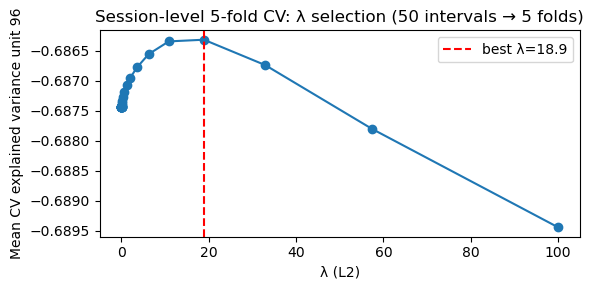

In [143]:
# choose best lambda (max mean CV score; ties -> smallest lambda)
best_idx = np.nanargmax(cv_mean_scores)
best_lambda = float(lambdas[best_idx])
print(f"Best lambda (session-level CV) = {best_lambda:.3f} (mean CV EV = {cv_mean_scores[best_idx]:.4f})")

# retrain on whole session with chosen lambda and compute final ev per unit
coef_final = fit_kernels(Xdm, pd.DataFrame(Y), best_lambda)
Y_pred_full = predict_activity(Xdm, coef_final).values
final_ev_per_unit = explained_variance(Y.flatten(), Y_pred_full.flatten())
final_ev_mean = float(np.nanmean(final_ev_per_unit))

print(f"Final explained variance (mean across units) on full session: {final_ev_mean:.4f}")

# save results for downstream use
session_lambda_search = {
    'lambdas': lambdas,
    'cv_mean_scores': cv_mean_scores,
    'best_lambda': best_lambda,
    'final_ev_per_unit': final_ev_per_unit,
    'final_ev_mean': final_ev_mean
}

# quick plot of CV curve
plt.figure(figsize=(6,3))
plt.plot(lambdas, cv_mean_scores, '-o')
plt.axvline(best_lambda, color='r', ls='--', label=f'best λ={best_lambda:.1f}')
plt.xlabel('λ (L2)')
plt.ylabel('Mean CV explained variance unit 96')
plt.title('Session-level 5-fold CV: λ selection (50 intervals → 5 folds)')
plt.legend()
plt.tight_layout()
plt.show()

In [147]:
from glms_plotting import *